(lq_robust_bewley)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 稳健 LQ 贝利模型

```{contents} Contents
:depth: 2
```

```{index} single: Robust Bewley Model
```

```{index} single: Observational Equivalence; heterogeneous agents
```

## 概述

本讲座将 {doc}`lq_bewley_complete_markets` 中的贝利经济嵌入到 {doc}`lq_robust_smoothing` 的稳健永久收入框架中。

这是关于 LQ 永久收入模型的四篇讲座中的最后一篇。

结果得到了一族经济体，其中的消费者对生成其收入的模型存在分歧，但行为却完全相同。

利用 {cite:t}`HST_1999` 的观测等价定理，我们证明了

- 连续统消费者 $i$ 如何在其稳健性参数 $\sigma_i \leq 0$ 和贴现因子 $\beta_i$ 上存在差异，只要每对 $(\sigma_i,\beta_i)$ 都位于一条观测等价轨迹上
- 每个这样的消费者如何选择与完全信任禀赋过程的基准 $(\sigma = 0, \beta)$ 代理人**相同的消费-储蓄规则**
- 均衡利率 $R = \beta^{-1}$ 以及所有总量和横截面动态因此如何与标准贝利模型的对应内容完全一致
- 尽管如此，不同的 $(\sigma_i,\beta_i)$ 代理人如何对其非金融收入持有真正不同的主观模型

该经济体是一个纯禀赋经济，因此没有实物资本，投资也不起任何作用。

我们将 {doc}`lq_robust_smoothing` 视为前置知识，并沿用其记号。

```{note}
与 {doc}`lq_robust_smoothing` 中一样，$w_{t+1}$ 是基准冲击，$v_{t+1}$ 是对其条件均值的扭曲，$\sigma \le 0$ 是稳健性参数，$\eta_1$ 和 $\eta_2$ 分别是永久性和暂时性禀赋冲击的标准差，$a_t$ 表示净资产。
```

让我们从一些导入开始。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 将贝利经济映射到 HST 框架

我们将 {doc}`lq_robust_smoothing` 中的稳健模型特殊化为 $\lambda = \delta_h = 0$，因此没有习惯效应也没有耐用品，并特殊化为不含实物资本的纯禀赋经济，即 $k_t = 0$。

在这种情况下，服务等于消费，即 $s_t = c_t$。

唯一交易的证券是一期无风险债券，$a_t$ 表示家庭的净资产头寸，因此正的 $a_t$ 表示财富。

禀赋过程遵循以下状态空间表示

$$
\begin{aligned}
z_{t+1} &= \check{A}\, z_t + \check{C}\, w_{t+1} \\
y_t &= \check{G}\, z_t
\end{aligned}
$$ (eq:rbew-endowment)

采用双因子设定 $y_t = z_{1t}+z_{2t}$，$\check A = \mathrm{diag}(1,0)$ 且 $\check C = \mathrm{diag}(\eta_1,\eta_2)$。

家庭的增广状态向量为 $x_t = [a_t,\; z_t^\top]^\top$，{doc}`lq_robust_smoothing` 中的运动规律特殊化为

$$
\begin{pmatrix} a_{t+1} \\ z_{t+1} \end{pmatrix}
=
\underbrace{\begin{pmatrix} R & R\check{G} \\ 0 & \check{A} \end{pmatrix}}_{A}
\begin{pmatrix} a_t \\ z_t \end{pmatrix}
+
\underbrace{\begin{pmatrix} -R \\ 0 \end{pmatrix}}_{B}
c_t
+
\underbrace{\begin{pmatrix} 0 \\ \check{C} \end{pmatrix}}_{C}
(w_{t+1} + v_{t+1})
$$ (eq:rbew-law)

目标函数为 $\mathbb{E}_0 \sum_{t=0}^\infty \beta^t\bigl[-(c_t - b)^2/2\bigr]$，这正是 $\sigma = 0$ 且极乐水平为常数 $b_t \equiv b$ 时的 HST 准则。

因此，当 $\sigma = 0$ 时，稳健贝尔曼方程恰好简化为 {doc}`lq_permanent_income` 中的 LQ 问题，从而证实 HST 框架内嵌了贝利模型。

## 该经济体的稳健性标量

对于稳健性而言，禀赋过程的一切相关信息都可归纳为 {doc}`lq_robust_smoothing` 中导出的标量 $\alpha^2$。

对于双因子禀赋，它是

$$
\alpha^2 = \eta_1^2 + (1-\beta)^2\,\eta_2^2
$$ (eq:rbew-alpha)

这是消费创新项 $h\,w_{t+1}$ 的方差，其中 $h = (1-\beta)\check G(I-\beta\check A)^{-1}\check C = \begin{pmatrix}\eta_1 & (1-\beta)\eta_2\end{pmatrix}$。

在当前的设定中，$\alpha^2$ 还有第二层同样具体的含义，这一点我们在 {doc}`lq_bewley_complete_markets` 中已经遇到过。

由于个人消费是创新方差为 $\alpha^2$ 的随机游走，从共同初始条件出发的年龄为 $t$ 的代理人之间的消费横截面方差恰好为 $t\,\alpha^2$。

因此，决定消费者稳健性担忧强度的那个标量，同样也决定了贝利横截面扩散的速度。

## 贝利观测等价轨迹

在均衡利率 $R = \beta^{-1}$ 处应用 {doc}`lq_robust_smoothing` 中的观测等价定理 {prf:ref}`thm-rcs-oe1`，可得**贝利观测等价轨迹**

$$
\hat\beta(\sigma) = \beta + \frac{\sigma\,\alpha^2\,\beta}{1-\beta}
$$ (eq:rbew-locus)

对于 $\sigma < 0$，我们有 $\hat\beta(\sigma) < \beta$。

具有 $(\sigma, \hat\beta(\sigma))$ 这一对参数的代理人对模型误设更为担忧，因为 $\sigma$ 更低，但同时也更不耐心，因为 $\hat\beta$ 更低。

这两种力量恰好相互抵消，使消费决策规则保持不变。

该轨迹只有在 {doc}`lq_robust_smoothing` 的崩溃点之上才是可行的，

$$
\underline\sigma = -\frac{(1-\beta)^2}{\alpha^2},
\qquad\text{此时}\qquad
\hat\beta(\underline\sigma) = \beta^2
$$ (eq:rbew-breakdown)

在 $\underline\sigma$ 以下，个体稳健控制问题无解，因此不存在可描述的经济体。

## 异质类型下的均衡

现在我们可以让连续统的类型来充实经济体，这些类型在其对稳健性的担忧程度上有所不同。

````{prf:proposition} 一个稳健贝利均衡
:label: prop-rbew-types

设单位区间内的每个代理人 $i$ 由稳健性参数 $\sigma_i \in (\underline\sigma, 0]$ 标示，其分布服从任意分布 $\Phi$，并设代理人 $i$ 具有贴现因子

$$
\beta_i = \hat\beta(\sigma_i) = \beta + \frac{\sigma_i\,\alpha^2\,\beta}{1-\beta}
$$ (eq:rbew-types)

使得每对 $(\sigma_i,\beta_i)$ 都位于轨迹 {eq}`eq:rbew-locus` 上。

那么

1. 每个代理人的最优消费计划都与标准 $(\sigma = 0,\, \beta)$ 代理人的相同，
2. 均衡总名义利率为 $R = \beta^{-1}$，与 $\Phi$ 无关，且
3. 总量和横截面动态与 {doc}`lq_bewley_complete_markets` 中基准贝利经济的对应内容一致。
````

````{prf:proof}
根据 {prf:ref}`thm-rcs-oe1`，面对总回报率 $R = \beta^{-1}$ 的具有参数 $(\sigma_i, \hat\beta(\sigma_i))$ 的代理人，会选择与基准 $(0,\beta)$ 代理人相同的消费-储蓄规则。

这一点对每个代理人都成立，并不要求所有 $\sigma_i$ 相等，由此得到第 1 部分。

由于所有个体规则都与基准规则一致，商品市场出清条件 $\int c_t^i\, di = Y$ 和债券市场条件 $\int a_t^i\, di = 0$ 就是基准条件，因此它们在 $R = \beta^{-1}$ 处得到满足，原因与 {doc}`lq_bewley_complete_markets` 中给出的完全相同。

由于市场出清从不涉及 $\Phi$，均衡利率也不涉及 $\Phi$，由此得到第 2 部分。

第 3 部分成立是因为总量和横截面对象是个体路径的积分，而个体路径正是基准路径。
````

因此，稳健性类型的分布 $\Phi$ 完全无法通过数量数据识别出来。

一位观察到每个代理人在每个日期的 $\{c_t^i, a_t^i\}$ 的计量经济学家无法判断该经济体是完全由 $\sigma_i = 0$ 的代理人组成，还是完全由 $\sigma_i$ 接近 $\underline\sigma$ 的代理人组成，抑或是任何混合。

## 代理人之间真正不同之处

轨迹上的代理人在他们*所做*的事情上无法区分，但在他们*所信*的事情上却可以区分。

具有 $\sigma_i < 0$ 的代理人会对其条件期望应用最坏情形扭曲 $v_{t+1}^i = K(\sigma_i,\beta_i)\,\mu_{s,t}^i$，而具有 $\sigma_i = 0$ 的代理人则照单全收近似模型。

根据 {doc}`lq_robust_smoothing`，代理人 $i$ 的边际效用的最坏情形规律为

$$
\mu_{s,t+1}^i = \zeta_i\, \mu_{st}^i + \alpha\, w_{t+1},
\qquad
\zeta_i = \frac{\beta}{\beta_i} = \left[1 + \frac{\sigma_i\alpha^2}{1-\beta}\right]^{-1} > 1
$$ (eq:rbew-zeta)

在 $\lambda = \delta_h = 0$ 且极乐点为常数的情况下，我们有 $\mu_{st} = b - c_t$，因此代理人 $i$ 的**最坏情形预期消费路径**为

$$
\hat{\mathbb{E}}_t\, c_{t+h}^i = b - \zeta_i^{\,h}\,(b - c_t)
$$ (eq:rbew-beliefs)

相比之下，在近似模型下，消费是一个鞅，即对于每个 $h$ 都有 $\mathbb{E}_t c_{t+h} = c_t$。

方程 {eq}`eq:rbew-beliefs` 表明，一个尚未达到极乐点的稳健代理人，在其最坏情形模型下预期消费将以几何速率 $\zeta_i$ *偏离*极乐点。

代理人越稳健，其防范的漂移速度就越快，进行的预防性储蓄也就越多。

而更低的 $\beta_i$ 恰好抵消了这一额外储蓄，这就是为什么所有类型实现的路径都相同的原因。

## 计算

我们使用前几篇讲座的校准。

In [2]:
β = 0.95        # benchmark discount factor, R = 1/β
η1 = 0.15       # std of permanent shock
η2 = 0.30       # std of transitory shock
b = 1.0         # bliss point

R = 1 / β
h = np.array([η1, (1 - β) * η2])       # consumption innovation loadings
α2 = h @ h
α = np.sqrt(α2)
σ_lo = -(1 - β)**2 / α2                # breakdown point, eq:rbew-breakdown

print(f"α^2 = {α2:.6f}   α = {α:.6f}")
print(f"breakdown σ̲ = {σ_lo:.6f},  where β̂ = {β + σ_lo * α2 * β / (1 - β):.6f}"
      f"  (β² = {β**2:.6f})")

α^2 = 0.022725   α = 0.150748
breakdown σ̲ = -0.110011,  where β̂ = 0.902500  (β² = 0.902500)


接下来我们构建一组分布在可行范围内的类型，并记录它们之间的区别。

我们沿用 {doc}`lq_robust_smoothing` 中的检测误差概率，来报告在 $T = 40$ 个季度的样本中，每种类型的最坏情形模型有多难被检测出来。

In [3]:
def worst_case_persistence(σ, β, α2):
    "Worst-case persistence ζ(σ) of marginal utility, eq:rbew-zeta."
    return 1 / (1 + σ * α2 / (1 - β))


def simulate_paths(ζ, α, T, n_paths, seed):
    "Simulate n_paths draws of μ_{t+1} = ζ μ_t + α w_{t+1} from μ_0 = 0."
    rng = np.random.default_rng(seed)
    paths = np.zeros((n_paths, T + 1))
    shocks = rng.standard_normal((n_paths, T))
    for t in range(T):
        paths[:, t + 1] = ζ * paths[:, t] + α * shocks[:, t]
    return paths


def log_likelihood_ratio(paths, ζ, α):
    "Return log p_worst(path) - log p_approx(path)."
    lag, lead = paths[:, :-1], paths[:, 1:]
    return 0.5 * (np.sum(((lead - lag) / α)**2, axis=1)
                  - np.sum(((lead - ζ * lag) / α)**2, axis=1))


def detection_error_probability(ζ, α, T=40, n_paths=10_000, seed=1234):
    "Finite-sample DEP for the approximating and worst-case scalar laws."
    if np.isclose(ζ, 1.0):
        return 0.5
    approx = simulate_paths(1.0, α, T, n_paths, seed)
    worst = simulate_paths(ζ, α, T, n_paths, seed + 1)
    return 0.5 * (np.mean(log_likelihood_ratio(worst, ζ, α) < 0)
                  + np.mean(log_likelihood_ratio(approx, ζ, α) > 0))

In [4]:
σ_types = np.array([0.0, 0.3, 0.6, 0.9]) * σ_lo
β_types = β + σ_types * α2 * β / (1 - β)
ζ_types = worst_case_persistence(σ_types, β, α2)
dep_types = np.array([detection_error_probability(ζ, α) for ζ in ζ_types])

print(f"{'σ_i':>10}{'β_i':>10}{'ζ_i':>10}{'DEP':>8}")
for σ_i, β_i, ζ_i, dep in zip(σ_types, β_types, ζ_types, dep_types):
    print(f"{σ_i:10.4f}{β_i:10.4f}{ζ_i:10.4f}{dep:8.3f}")

       σ_i       β_i       ζ_i     DEP
   -0.0000    0.9500    1.0000   0.500
   -0.0330    0.9357    1.0152   0.426
   -0.0660    0.9215    1.0309   0.333
   -0.0990    0.9072    1.0471   0.233


这四种类型在耐心程度和其最坏情形模型的悲观程度上存在实质性差异。

我们现在确认，尽管如此，它们的行为仍然完全相同。

每种类型都面对相同的冲击，并从相同的初始消费出发，每种类型都按照基准规则 $c_{t+1} = c_t + h\,w_{t+1}$ 进行消费。

In [5]:
T = 60
rng = np.random.default_rng(42)
shocks = rng.standard_normal((T, 2))          # common shocks for all types

c_paths = np.zeros((len(σ_types), T + 1))
for i in range(len(σ_types)):
    for t in range(T):
        c_paths[i, t + 1] = c_paths[i, t] + h @ shocks[t]

print("max absolute difference across types:"
      f" {np.abs(c_paths - c_paths[0]).max():.2e}")

max absolute difference across types: 0.00e+00


各路径完全一致，这正是 {prf:ref}`prop-rbew-types` 第 1 部分的体现。

下图对比了各类型的行为与其信念之间的差异。

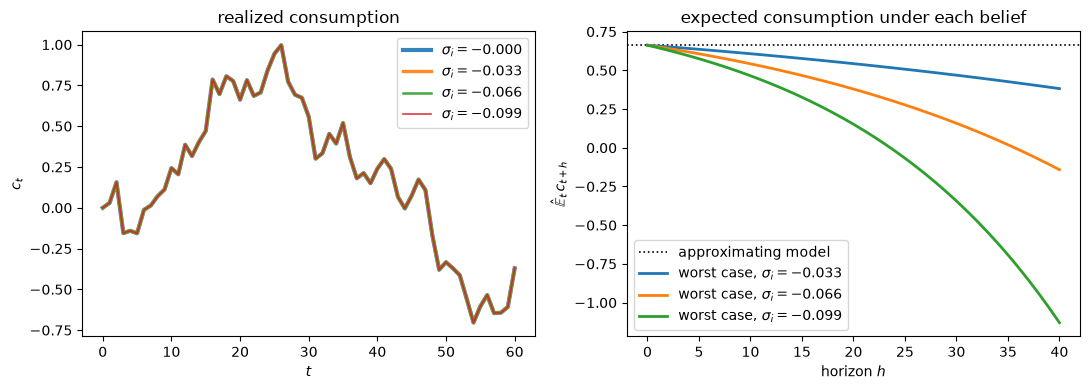

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for i, σ_i in enumerate(σ_types):
    axes[0].plot(c_paths[i], lw=3 - 0.6 * i, alpha=0.9,
                 label=rf'$\sigma_i={σ_i:.3f}$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$c_t$')
axes[0].set_title('realized consumption')
axes[0].legend()

horizons = np.arange(41)
c_now = c_paths[0, 20]
axes[1].axhline(c_now, color='k', linestyle=':', lw=1.2,
                label='approximating model')
for σ_i, ζ_i in zip(σ_types, ζ_types):
    if σ_i == 0.0:
        continue
    axes[1].plot(horizons, b - ζ_i**horizons * (b - c_now), lw=2,
                 label=rf'worst case, $\sigma_i={σ_i:.3f}$')
axes[1].set_xlabel('horizon $h$')
axes[1].set_ylabel(r'$\hat{\mathbb{E}}_t\,c_{t+h}$')
axes[1].set_title('expected consumption under each belief')
axes[1].legend()

fig.tight_layout()
plt.show()

{numref}`fig-rbew-beliefs` 的左图显示了四条完全重叠的曲线。

右图则表明，同样这四个代理人对未来的预期却截然不同。

$\sigma_i = 0$ 的代理人预期消费将维持在原地不动。

每个稳健代理人都在防范消费从极乐点漂移出去的未来，代理人越稳健，漂移速度就越快。

最后我们检验 {prf:ref}`prop-rbew-types` 的第 3 部分，即横截面的行为与基准贝利经济一致。

我们模拟一个大规模的人群，其中每个代理人自行抽取其类型和冲击，并将消费的横截面方差与基准预测 $t\,\alpha^2$ 进行比较。

In [7]:
n_agents, T = 20_000, 40
rng = np.random.default_rng(1234)

# each agent draws a robustness type; types do not affect behaviour
σ_i = rng.uniform(σ_lo, 0.0, size=n_agents)

shocks = rng.standard_normal((n_agents, T, 2))
c = np.zeros((n_agents, T + 1))
c[:, 1:] = np.cumsum(shocks @ h, axis=1)

print(f"{'t':>5}{'cross-section var':>20}{'t·α²':>12}")
for t in [10, 20, 30, 40]:
    print(f"{t:5d}{c[:, t].var():20.5f}{t * α2:12.5f}")

    t   cross-section var        t·α²
   10             0.22744     0.22725
   20             0.45652     0.45450
   30             0.67723     0.68175
   40             0.89604     0.90900


横截面方差以速率 $\alpha^2$ 线性增长，与 {doc}`lq_bewley_complete_markets` 中的结果完全一致，稳健性类型的分布在数据中不留下任何痕迹。

## 结语

我们将单代理人的稳健永久收入模型嵌入到一个贝利均衡中，该均衡中包含了在多大程度上不信任其收入过程方面存在差异的连续统代理人。

只要每个代理人的一对 $(\sigma_i,\beta_i)$ 位于观测等价轨迹 {eq}`eq:rbew-locus` 上，每个代理人就都会选择基准消费规则。

均衡利率 $R = \beta^{-1}$、总量动态以及消费横截面方差的线性增长，都完全不变地继承自 {doc}`lq_bewley_complete_markets` 中标准的贝利模型。

这是一个很强的不可识别性结果。

数量数据能够确定决策规则，但无法将其分解为不耐心程度和对模型误设的担忧程度。

这些代理人*不*共有的是他们对世界的看法：每个稳健类型的行为就好像其消费即将以自己的速率 $\zeta_i$ 偏离极乐点一样。

有两条途径可以摆脱这种观测等价性。

一是关注资产价格，资产价格确实能够区分 $(\sigma,\hat\beta)$ 对，这一点在 {doc}`robust_permanent_income` 中有所研究。

另一条是利用 {doc}`lq_robust_smoothing` 中的检测误差概率，从统计上界定 $\sigma$ 的合理范围。

## 练习

```{exercise-start}
:label: rbew_ex1
```

本练习要求你完成从基准贝利经济到 HST 记号的转换。

将稳健控制设定特殊化为无习惯、无资本的 LQ 贝利环境，即 $\lambda = \delta_h = 0$ 且 $k_t = 0$，并令禀赋遵循双因子模型。

1. 将家庭状态写为 $x_t = [a_t, z_t^\top]^\top$，其中 $a_t$ 为净资产，并推导出 {eq}`eq:rbew-law` 中的矩阵 $(A, B, C)$。

2. 证明当 $\sigma = 0$ 时，贝尔曼问题与 {doc}`lq_permanent_income` 中的 LQ 永久收入问题一致。

3. HST 定义 $\alpha^2 = \nu^\top\nu$，其中 $\nu^\top = M_s C$，$\mu_{st} = M_s x_t$。计算该经济体的 $M_s$，并验证这一途径能得到与 {eq}`eq:rbew-alpha` 相同的 $\alpha^2$。

```{exercise-end}
```

```{solution-start} rbew_ex1
:class: dropdown
```

以下是一种解法。

1. 根据预算法则 $a_{t+1} = R(a_t + y_t - c_t)$，$y_t = \check G z_t$ 以及 $z_{t+1} = \check A z_t + \check C w_{t+1}$，堆叠可得

$$
\begin{pmatrix} a_{t+1} \\ z_{t+1} \end{pmatrix}
=
\underbrace{\begin{pmatrix} R & R\check G \\ 0 & \check A \end{pmatrix}}_{A}
\begin{pmatrix} a_t \\ z_t \end{pmatrix}
+
\underbrace{\begin{pmatrix} -R \\ 0 \end{pmatrix}}_{B} c_t
+
\underbrace{\begin{pmatrix} 0 \\ \check C \end{pmatrix}}_{C} w_{t+1} .
$$

  $B$ 的符号为负，因为更高的 $c_t$ 会减少资产积累。

2. 在 $\sigma = 0$ 时，最小化代理人不存在，扭曲项从贝尔曼方程中消失，目标函数为 $\mathbb{E}_0\sum \beta^t[-(c_t-b)^2/2]$，受限于线性运动规律。

  这正是 LQ 永久收入问题。

3. 在 $\lambda = \delta_h = 0$ 且极乐点为常数时，$\mu_{st} = b - c_t$，最优规则为

$$
c_t = (1-\beta)\bigl[a_t + \check G(I-\beta\check A)^{-1} z_t\bigr] + \text{常数},
$$

  因此除常数外，$M_s = -(1-\beta)\begin{pmatrix}1 & \check G(I-\beta\check A)^{-1}\end{pmatrix}$。

  由于 $C = [0;\ \check C]$，$M_s$ 的第一列被消去，

$$
\nu^\top = M_s C = -(1-\beta)\check G(I-\beta\check A)^{-1}\check C = -h .
$$

  因此 $\alpha^2 = \nu^\top\nu = hh^\top = \eta_1^2 + (1-\beta)^2\eta_2^2$，与 {eq}`eq:rbew-alpha` 一致。

  负号无关紧要，因为只有 $\alpha^2$ 会出现。

```{solution-end}
```

```{exercise-start}
:label: rbew_ex2
```

本练习将逐步推导 {prf:ref}`prop-rbew-types` 中的均衡逻辑。

固定一个基准对 $(\beta, \sigma = 0)$，令 $R = \beta^{-1}$，并令单位区间内的消费者由 $i$ 标示，类型为 $\sigma_i \in (\underline\sigma, 0]$，贴现因子为来自 {eq}`eq:rbew-locus` 的 $\beta_i = \hat\beta(\sigma_i)$。

1. 使用 {doc}`lq_robust_smoothing` 中的 {prf:ref}`thm-rcs-oe1` 证明每种类型与基准 $(\beta, 0)$ 代理人具有相同的消费规则。

2. 证明商品市场和债券市场出清意味着与标准贝利模型相同的均衡利率 $R = \beta^{-1}$，无论类型的分布如何。

3. 解释为什么代理人在数量上可以观测等价，但持有不同的最坏情形主观模型。

4. 假设代理人具有共同的 $\beta$，但在 $\sigma_i$ 上有所不同，即它们*不*位于该轨迹上。解释为什么在这种情况下 $R = \beta^{-1}$ 通常无法使债券市场出清。

```{exercise-end}
```

```{solution-start} rbew_ex2
:class: dropdown
```

以下是一种解法。

1. {prf:ref}`thm-rcs-oe1` 表明，如果 $(\sigma_i,\beta_i)$ 满足 $\beta_i = \beta + \sigma_i\alpha^2\beta/(1-\beta)$，则类型 $i$ 选择的决策规则与基准代理人相同，因此所有类型共享策略函数 $c_t = \mathcal{C}(a_t, z_t)$。

2. 由于所有个体规则都与基准规则一致，对 $i$ 进行加总便重现了基准的市场出清条件，而该条件在 $R = \beta^{-1}$ 处成立。

  类型分布从未介入其中，因此不会影响均衡利率。

3. 观测等价性是关于由最优规则生成的数量的一种表述。

  最小化反馈 $K(\sigma_i,\beta_i)$ 在不同类型之间仍然存在差异，因此各代理人在做出相同选择的同时，对相同的冲击过程赋予了不同的最坏情形条件均值。

4. 在轨迹之外，不耐心的抵消作用就消失了。

  一个具有 $\sigma_i < 0$ 且贴现因子为 $\beta$ 的代理人具有未被抵消的预防性动机，因此在 $R = \beta^{-1}$ 时它想要比基准代理人储蓄更多。

  在总体上对债券存在正的净需求的情况下，均衡利率必须降至 $\beta^{-1}$ 以下才能使市场出清，此时均衡就依赖于整个类型分布。

```{solution-end}
```

```{exercise-start}
:label: rbew_ex3
```

本练习针对两个个体代理人，将数量与信念区分开来。

考虑代理人 $a$ 和 $b$，其中 $\sigma^a < \sigma^b \leq 0$，二者都位于轨迹 {eq}`eq:rbew-locus` 上。

1. 证明这两个代理人具有相同的消费创新 $h\,w_{t+1}$。

2. 证明如果它们从相同的 $(a_t, z_t)$ 出发，并观测到相同的冲击 $w_{t+1}$，则它们下一期的消费和资产是一致的。

3. 利用 {eq}`eq:rbew-beliefs`，计算两个代理人关于 $b - c_{t+h}$ 的最坏情形预测之比，并证明其随 $h$ 呈几何增长。

4. 总结仅凭数量数据能够识别什么，不能识别什么。

```{exercise-end}
```

```{solution-start} rbew_ex3
:class: dropdown
```

以下是一种解法。

1. 两对参数都位于 {eq}`eq:rbew-locus` 上，因此根据 {prf:ref}`thm-rcs-oe1`，两者都使用基准规则，因而具有相同的创新向量 $h$。

2. 在共同的状态和共同的冲击下，两个代理人都采用相同的策略函数和相同的运动规律，因此 $c_{t+1}^a = c_{t+1}^b$ 且 $a_{t+1}^a = a_{t+1}^b$。

3. 由 {eq}`eq:rbew-beliefs` 可知，$\hat{\mathbb{E}}_t (b - c_{t+h}^j) = \zeta_j^{\,h}(b-c_t)$，因此比值为 $(\zeta_a/\zeta_b)^h$。

  由于 $\sigma^a < \sigma^b$ 意味着 $\zeta_a > \zeta_b$，该比值呈几何增长：随着期限的延长，这两个代理人的信念会无限发散，尽管它们的行为从未有任何不同。

4. 数量数据可以确定均衡决策规则，从而确定出现在其中的参数的单一组合。

  它们无法沿着该轨迹将这一规则分解为不耐心 $\beta_i$ 和稳健性 $\sigma_i$。

```{solution-end}
```

```{exercise-start}
:label: rbew_ex4
```

本练习探讨在统计上有多少信念异质性是合理的。

将关注范围限制在其最坏情形模型在 $T = 40$ 的样本中检测误差概率至少为 $0.2$ 的类型上。

1. 通过二分法找到最稳健的可行类型 $\sigma^{\min}$。

2. 对于该类型，报告 $\beta_i$、$\zeta_i$，以及使其对 $b - c_{t+h}$ 的最坏情形预测达到近似模型预测两倍的期限 $h$。

3. 将第 1 部分中的 $T$ 改为 $160$ 重复计算，并评述更长样本对信念异质性合理程度的影响。

```{exercise-end}
```

```{solution-start} rbew_ex4
:class: dropdown
```

以下是一种解法。

近似模型对每个 $h$ 都预测 $b - c_{t+h} = b - c_t$，而最坏情形预测为 $\zeta_i^h(b-c_t)$，因此加倍期限满足 $\zeta_i^h = 2$。

In [8]:
def σ_for_target_dep(target, T, β, α2, tol=1e-5):
    """
    Find σ ∈ (σ̲, 0) with DEP(σ) = target by bisection.

    Returns None if the DEP never falls to the target on the admissible
    range, in which case the breakdown point is the binding constraint.
    """
    α_loc = np.sqrt(α2)
    lo, hi = 0.999 * (-(1 - β)**2 / α2), 0.0

    def dep_at(σ):
        return detection_error_probability(
            worst_case_persistence(σ, β, α2), α_loc, T=T)

    if dep_at(lo) > target:
        return None

    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        if dep_at(mid) < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


for T in [40, 160]:
    σ_min = σ_for_target_dep(0.2, T, β, α2)
    if σ_min is None:
        σ_min = 0.999 * σ_lo        # breakdown binds before detectability
        note = ' (breakdown point binds)'
    else:
        note = ''
    ζ_min = worst_case_persistence(σ_min, β, α2)
    print(f"T = {T:>3}:  σ_min = {σ_min:.5f}   β_i = {β / ζ_min:.5f}   "
          f"ζ_i = {ζ_min:.5f}   doubling horizon = "
          f"{np.log(2) / np.log(ζ_min):.1f} quarters{note}")

T =  40:  σ_min = -0.10990   β_i = 0.90255   ζ_i = 1.05258   doubling horizon = 13.5 quarters (breakdown point binds)
T = 160:  σ_min = -0.02806   β_i = 0.93788   ζ_i = 1.01292   doubling horizon = 54.0 quarters


T = 160:  σ_min = -0.02806   β_i = 0.93788   ζ_i = 1.01292   doubling horizon = 54.0 quarters


在 $T = 40$ 时，检测误差概率在可行范围内从未降至 $0.2$，因此最稳健的合理类型就是崩溃点本身对应的类型。

在 $T = 160$ 时，统计可检测性首先成为约束，合理类型集合急剧向 $\sigma = 0$ 收缩。

加倍期限相应地延长了：随着数据的增多，只有那些悲观情绪累积缓慢的代理人在统计上仍然可信。

```{solution-end}
```

## 相关讲座

- {doc}`lq_permanent_income` 阐述了标准的 LQ 永久收入模型。
- {doc}`lq_bewley_complete_markets` 构建了基准贝利经济，其均衡在本讲座中得到重现。
- {doc}`lq_robust_smoothing` 推导了本讲座中使用的观测等价定理、崩溃点和检测误差概率。
- {doc}`robust_permanent_income` 展示了资产价格如何打破观测等价性。